In [1]:
import sys

sys.path.append("..")

In [1]:
%matplotlib inline
from carrefour_receipts_api.utils import display_amounts_month
import pandas as pd

In [2]:
table_amounts = pd.read_csv("../data/20250601-carrefour_amounts.csv", parse_dates=["dateKey"])

In [17]:
table_amounts.head()

,id,dateKey,recordType,totalAmountBeforeDiscount,couponDiscount,totalAmountImmediateDiscount,totalAmountDeferredDiscount,totalEarnedAmount,totalPaidAmount,vatTotalProductsAt20,...,CBPASS,Cagnotte fidélité,Carte PASS,Carte bancaire,Espèces,PAYPAL,Titre restaurant/service,eLOYALTY,payment.type.label.returned,totalTrueAmount
0,3020180195621_20241031_32-299-1553,2024-10-31,receipt,4.18,0.0,0.00,0.00,0.0,4.18,4.18,...,0.0,0.00,0.00,4.18,0,0.0,0.0,0.0,0.0,4.18
1,3020180195621_20241130_25-221-1627,2024-11-30,receipt,5.56,0.0,0.00,0.00,0.0,5.56,0.00,...,0.0,5.56,0.00,0.00,0,0.0,0.0,0.0,0.0,0.00
2,3020339801200_20220425_6-227-1648,2022-04-25,receipt,79.81,0.0,-1.12,0.39,0.0,78.69,8.59,...,0.0,0.00,78.69,0.00,0,0.0,0.0,0.0,0.0,78.69
3,3020339801200_20220426_3-48-1109,2022-04-26,receipt,126.50,0.0,0.00,7.77,0.0,126.50,98.14,...,0.0,0.00,126.50,0.00,0,0.0,0.0,0.0,0.0,126.50
4,3020339801200_20220503_1-9-1015,2022-05-03,receipt,79.56,0.0,0.00,4.85,0.0,79.56,18.90,...,0.0,0.00,79.56,0.00,0,0.0,0.0,0.0,0.0,79.56


In [4]:
# Group by year and sum the amounts
table_yearly_amounts = (
    table_amounts.groupby(pd.Grouper(key="dateKey", freq="Y")).sum(numeric_only=True).reset_index()
)
table_monthly_amounts = (
    table_amounts.groupby(pd.Grouper(key="dateKey", freq="M")).sum(numeric_only=True).reset_index()
)

In [5]:
table_amounts.groupby(table_amounts.dateKey.dt.year).sum(numeric_only=True)

,totalAmountBeforeDiscount,couponDiscount,totalAmountImmediateDiscount,totalAmountDeferredDiscount,totalEarnedAmount,totalPaidAmount,vatTotalProductsAt20,vatTotalProductsAt5,vatTotalProductsAt10,vatAt5,...,CBPASS,Cagnotte fidélité,Carte PASS,Carte bancaire,Espèces,PAYPAL,Titre restaurant/service,eLOYALTY,payment.type.label.returned,totalTrueAmount
dateKey,,,,,,,,,,,,,,,,,,,,,
2022,4809.66,-85.00,-383.34,125.11,0.00,4426.32,1609.18,3018.550000,62.34,157.09,...,0.00,213.19,3719.51,419.15,0,0.00,102.0,0.00,-97.79,4204.9450
2023,8619.55,-309.00,-1021.59,737.29,0.00,7597.96,2818.26,5370.390000,119.94,279.64,...,0.00,821.64,3235.46,910.10,0,0.00,110.5,0.00,-219.96,6647.0891
2024,8596.65,-705.00,-1421.39,233.12,31.20,7173.16,2427.36,5445.740909,161.49,283.43,...,0.00,484.83,2044.81,104.33,0,432.34,17.0,122.57,-250.44,6363.5865
2025,3326.90,-220.07,-415.05,182.25,49.61,2907.30,873.08,2293.636364,26.33,119.59,...,30.99,344.40,643.87,0.00,1,0.00,0.0,64.94,-1.00,2413.6471


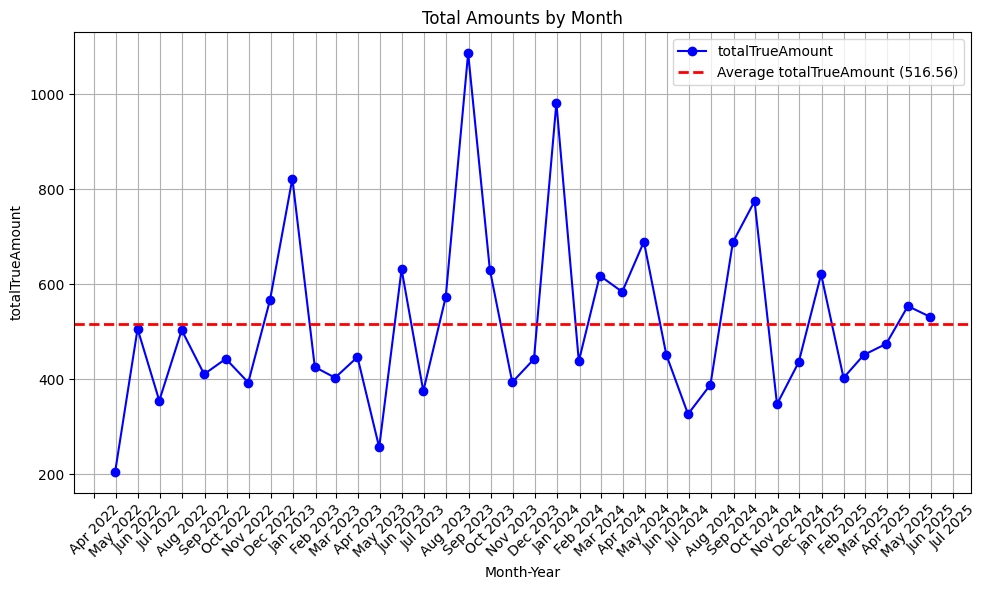

In [6]:
display_amounts_month(table_monthly_amounts, col_amount="totalTrueAmount", col_date="dateKey")

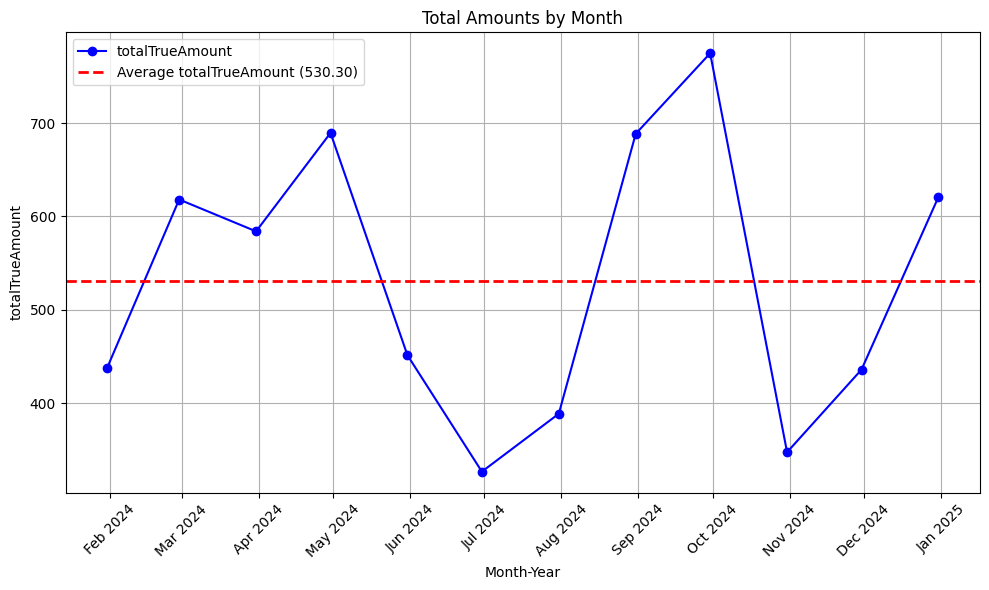

In [7]:
display_amounts_month(
    table_monthly_amounts[table_monthly_amounts["dateKey"].dt.year == 2024],
    col_amount="totalTrueAmount",
    col_date="dateKey",
)

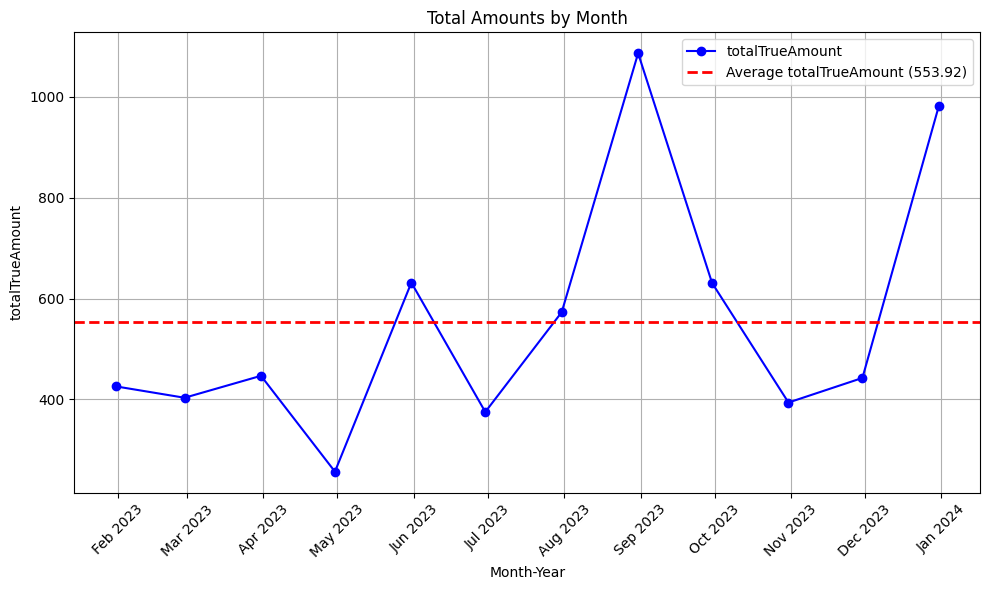

In [8]:
display_amounts_month(
    table_monthly_amounts[table_monthly_amounts["dateKey"].dt.year == 2023],
    col_amount="totalTrueAmount",
    col_date="dateKey",
)

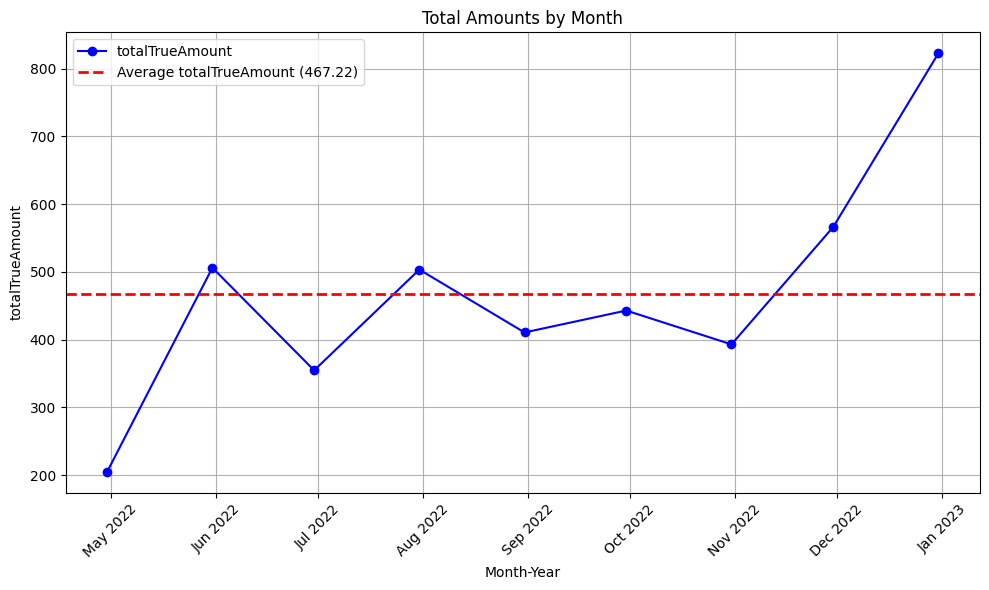

In [9]:
display_amounts_month(
    table_monthly_amounts[table_monthly_amounts["dateKey"].dt.year == 2022],
    col_amount="totalTrueAmount",
    col_date="dateKey",
)

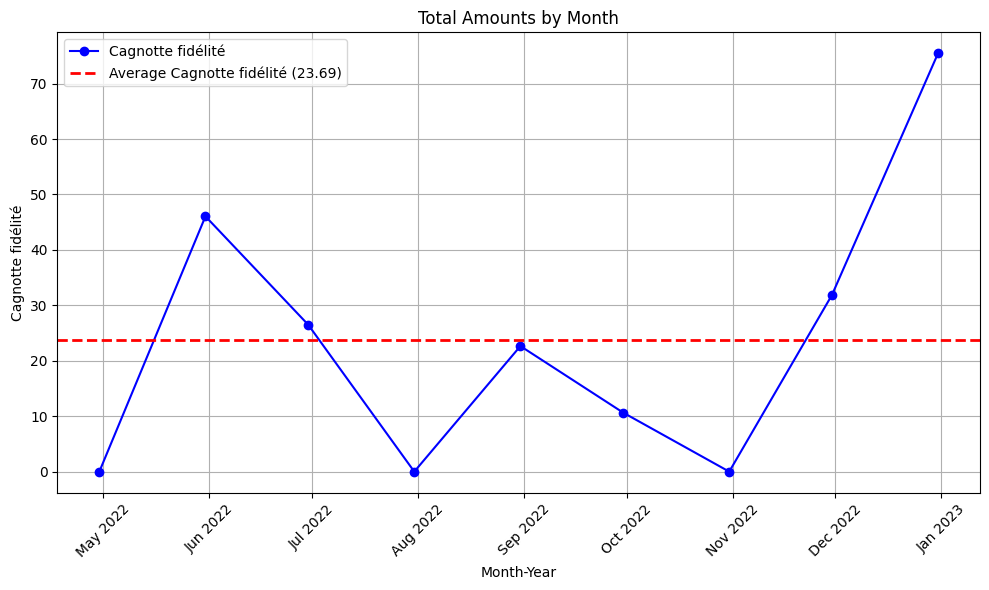

In [10]:
display_amounts_month(
    table_monthly_amounts[table_monthly_amounts["dateKey"].dt.year == 2022],
    col_amount="Cagnotte fidélité",
    col_date="dateKey",
)

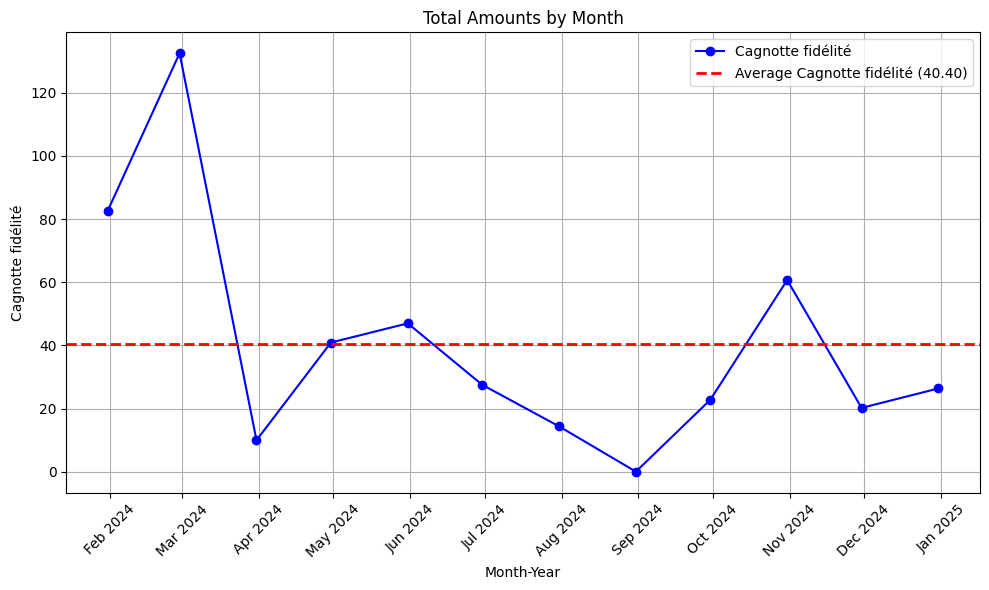

In [11]:
display_amounts_month(
    table_monthly_amounts[table_monthly_amounts["dateKey"].dt.year == 2024],
    col_amount="Cagnotte fidélité",
    col_date="dateKey",
)

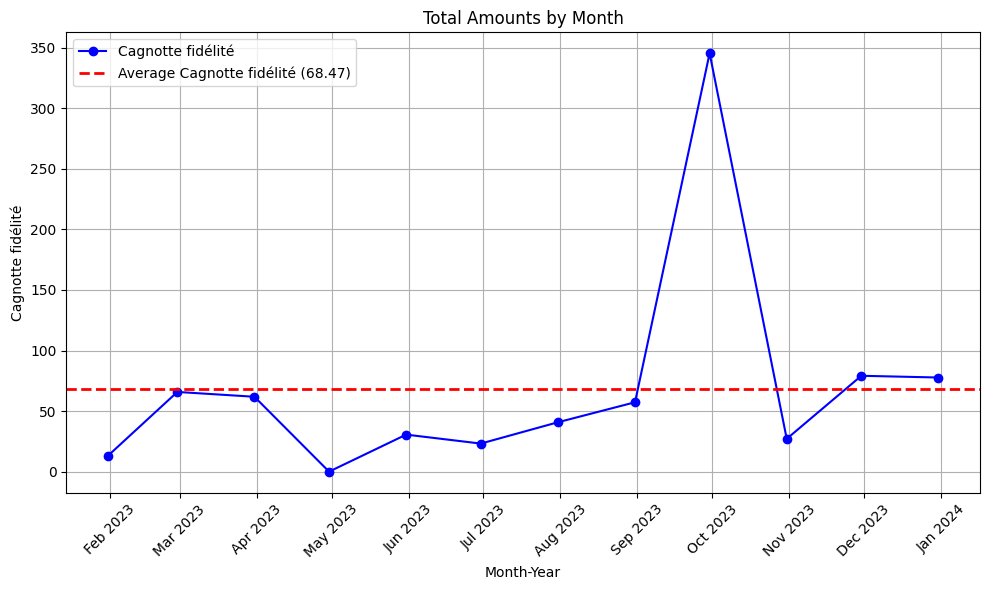

In [12]:
display_amounts_month(
    table_monthly_amounts[table_monthly_amounts["dateKey"].dt.year == 2023],
    col_amount="Cagnotte fidélité",
    col_date="dateKey",
)

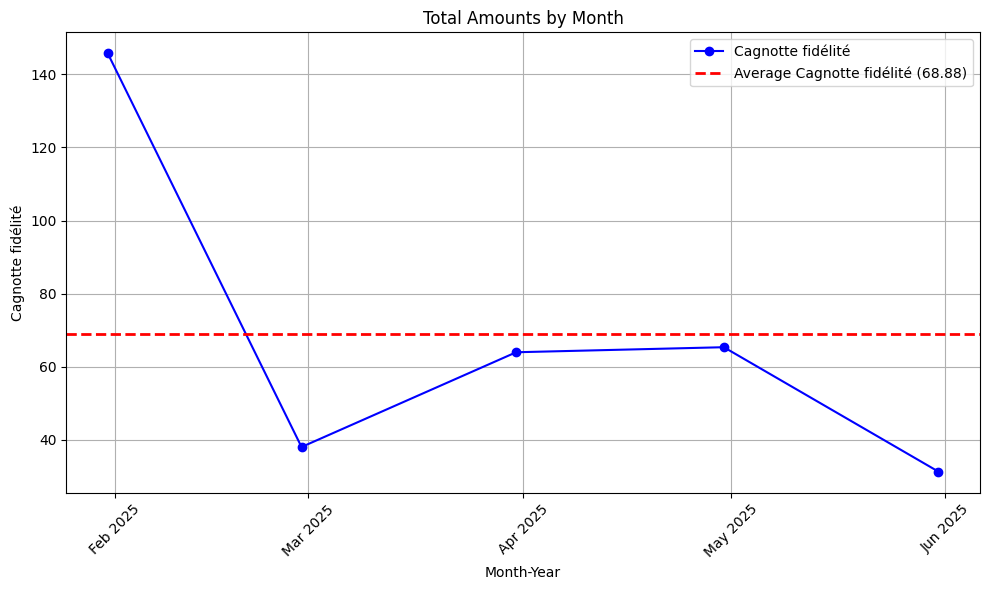

In [13]:
display_amounts_month(
    table_monthly_amounts[table_monthly_amounts["dateKey"].dt.year == 2025],
    col_amount="Cagnotte fidélité",
    col_date="dateKey",
)

# Analysis of loyalty

In [14]:
df_loyalty = pd.read_csv("../data/20250601-carrefour_loyalty.csv", parse_dates=["date"])

In [15]:
df_loyalty.groupby(by=df_loyalty["date"].dt.year).sum(numeric_only=True)

,operationId,earned,burned,itemRd
date,,,,
2024,36220450407195,3101.03,-915.97,580.69
2025,24322672497060,4958.56,-738.25,647.80


The analysis cannot be really accurate. However, we might be able to complete a bit the deferredAmount by month for example in the 2024 and 2025 by this:

In [26]:
grouped_loyalty_earned = (
    table_amounts[
        (table_amounts["dateKey"].dt.year == 2024) | (table_amounts["dateKey"].dt.year == 2025)
    ][["dateKey", "totalAmountDeferredDiscount", "totalEarnedAmount"]]
    .groupby(by=[table_amounts.dateKey.dt.year, table_amounts.dateKey.dt.month])
    .sum(numeric_only=True)
)

In [30]:
grouped_loyalty_earned

totalAmountDeferredDiscount  totalEarnedAmount
dateKey dateKey                                                
2024    1                              28.88               0.00
        2                             175.82               0.00
        3                              23.15               0.39
        4                               0.68               6.19
        5                               4.59               4.56
        6                               0.00               0.94
        7                               0.00               0.00
        8                               0.00               2.76
        9                               0.00               5.40
        10                              0.00              10.96
        11                              0.00               0.00
        12                              0.00               0.00
2025    1                               0.00              42.84
        2                              10.35               6.77
        3                              58.00               0.00
        4                              48.19               0.00
        5                              65.71               0.00

In [31]:
grouped_loyalty_spent = df_loyalty.groupby(
    by=[df_loyalty["date"].dt.year, df_loyalty["date"].dt.month]
).sum(numeric_only=True)

In [33]:
grouped_loyalty_spent

operationId   earned  burned  itemRd
date date                                        
2024 5     1261582464481    62.25  -46.97   29.15
     6     3532616999248   133.96 -114.00   33.84
     7     6070529460256   679.92  -94.36   72.60
     8     5352715664552   203.88  -51.28   64.40
     9     8713353540520  1225.76 -217.08  197.08
     10    5687472360556   437.20 -258.80   94.20
     11    3380703461160   147.64  -80.76   44.36
     12    2221476456422   210.42  -52.72   45.06
2025 1     5229204732115  2142.32 -323.16  315.72
     2     4967700270905   363.72  -76.06   53.78
     3     4706242344906  1000.94 -127.92  116.10
     4     7189781852584   803.04 -130.68   96.46
     5     2229743296550   648.54  -80.43   65.74

In [29]:
grouped_loyalty_spent.index

MultiIndex([(2024,  5),
            (2024,  6),
            (2024,  7),
            (2024,  8),
            (2024,  9),
            (2024, 10),
            (2024, 11),
            (2024, 12),
            (2025,  1),
            (2025,  2),
            (2025,  3),
            (2025,  4),
            (2025,  5)],
           names=['date', 'date'])

In [ ]:
grouped_loyalty = (
    table_amounts[
        (table_amounts["dateKey"].dt.year == 2024) | (table_amounts["dateKey"].dt.year == 2025)
    ][["dateKey", "totalAmountDeferredDiscount", "totalEarnedAmount"]]
    .groupby(by=[table_amounts.dateKey.dt.year, table_amounts.dateKey.dt.month])
    .sum(numeric_only=True)
)

grouped_loyalty_all = grouped_loyalty.join(
    other=grouped_loyalty_spent, on=["dateKey", "date"], how="inner"
)

KeyError: 'date'

In [19]:
grouped_loyalty

totalAmountDeferredDiscount  totalEarnedAmount
dateKey dateKey                                                
2024    1                              28.88               0.00
        2                             175.82               0.00
        3                              23.15               0.39
        4                               0.68               6.19
        5                               4.59               4.56
        6                               0.00               0.94
        7                               0.00               0.00
        8                               0.00               2.76
        9                               0.00               5.40
        10                              0.00              10.96
        11                              0.00               0.00
        12                              0.00               0.00
2025    1                               0.00              42.84
        2                              10.35               6.77
        3                              58.00               0.00
        4                              48.19               0.00
        5                              65.71               0.00